# Dataset Description
## Time spend on personal activities by age group

**Source**: DANE

**Download**: [Link](https://www.dane.gov.co/index.php/estadisticas-por-tema/pobreza-y-condiciones-de-vida/encuesta-nacional-del-uso-del-tiempo-enut)

# Code
## Imports

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [8]:
path = "./data/tiempo_por_participante.csv"

cols = [
    "Periodo",
    "Grupo",
    "Categoria",
    "Actividad",
    "Sexo",
    "hh:mm"
]

df = pd.read_csv(path, encoding="utf-8", usecols=cols)

In [9]:
df_f = df[
    (df["Periodo"].str.contains("2025")) &
    (df["Grupo"].str.lower().str.contains("edad")) &
    (df["Sexo"].str.lower().eq("total")) &
    ~(df["Actividad"].eq("Actividades personales")) &
    ~(df["Actividad"].eq("Actividades de cuidado personal")) &
    ~(df["Actividad"].eq("Actividades conexas a las actividades personales"))
  ][["Categoria", "Actividad", "hh:mm"]]

activities = {}
for i in df_f["Actividad"].unique():
    activities[i] = df_f[df_f["Actividad"].eq(i)][["Categoria", "hh:mm"]].set_index("Categoria")

## Plot

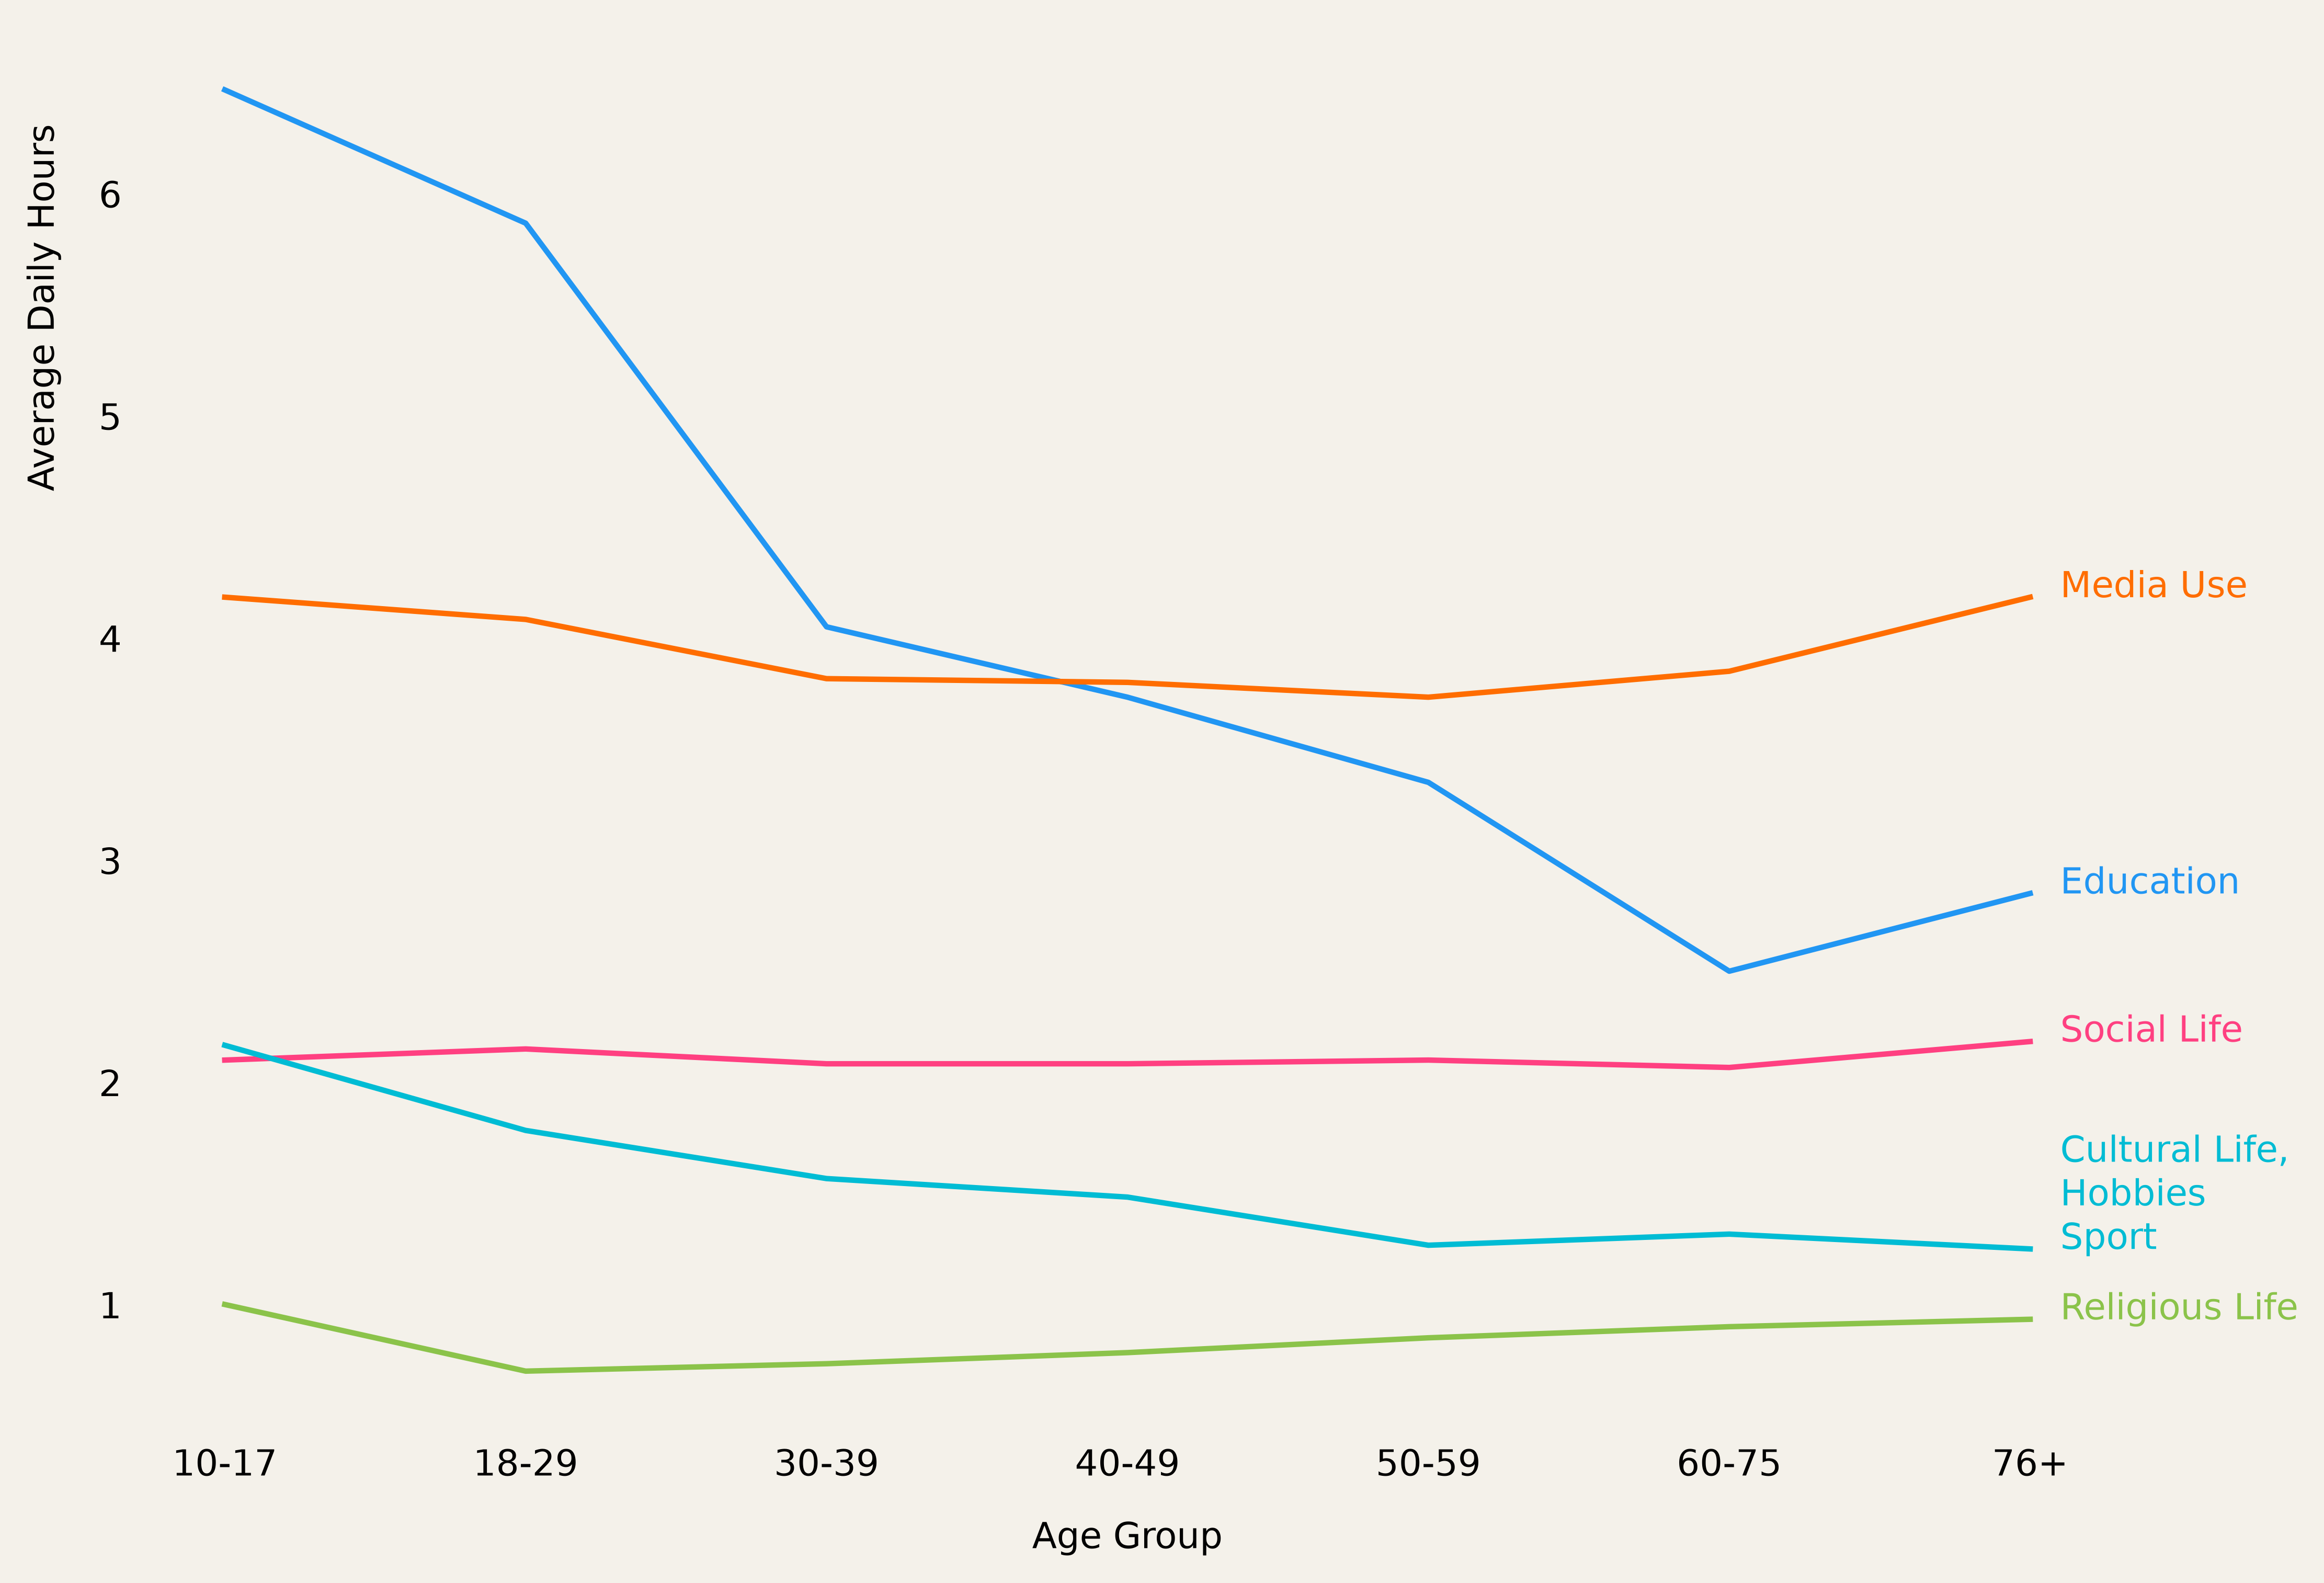

In [10]:
background = "#F4F1EA"

activities_en = [
    "Education",
    "Social Life",
    "Cultural Life,\nHobbies\nSport",
    "Media Use",
    "Religious Life",
]

colors = [
    "#2196F3",
    "#FF4081",
    "#00BCD4",
    "#FF6D00",
    "#8BC34A",
]

def to_hours(t):
    h, m = map(int, t.split(":"))
    return h + m / 60

x_labels = ["10-17", "18-29", "30-39", "40-49", "50-59", "60-75", "76+"]

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

for x, i in enumerate(df_f["Actividad"].unique()):
    y = activities[i]["hh:mm"].apply(to_hours)
    plt.plot(y, color=colors[x])
    plt.annotate(
        activities_en[x],
        xy=(len(y)-1 + 0.1, y.iloc[-1]),
        color=colors[x]
    )

plt.xticks(range(len(x_labels)), x_labels)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Average Daily Hours", labelpad=10, fontsize=10, y=0.8)
plt.xlabel("Age Group", labelpad=10, fontsize=10)

plt.show()